## 4. Evaluation Metrics for Classification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [3]:
df = pd.read_csv('/workspaces/ml-zoomcamp/03-classification/data-week-3.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
categorical_variables = list(df.dtypes[df.dtypes == 'str'].index)

In [7]:
print(categorical_variables)

['customerid', 'gender', 'partner', 'dependents', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'totalcharges', 'churn']


In [8]:
for c in categorical_variables:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [9]:
df[['multiplelines']].values

array([['no_phone_service'],
       ['no'],
       ['no'],
       ...,
       ['no_phone_service'],
       ['yes'],
       ['no']], shape=(7043, 1), dtype=object)

In [10]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')

In [11]:
df.totalcharges = df.totalcharges.fillna(0)

In [12]:
df.churn = (df.churn == 'yes').astype(int)

In [13]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [14]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [15]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [16]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

In [17]:
del df_train['churn']
del df_val['churn']
del df_test['churn']

In [18]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [19]:
dv = DictVectorizer(sparse=False)
dicts_train = df_train[numerical+categorical].to_dict(orient='records')
X_train = dv.fit_transform(dicts_train)

In [20]:
model=LogisticRegression(solver='liblinear', max_iter = 100)
model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some pen

In [21]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [22]:
y_pred = model.predict_proba(X_val)[:,1]
churn_decision = (y_pred>=0.5)
(y_val == churn_decision).mean()

np.float64(0.8055358410220014)

##### We want to know if this 80.55% is good?

### 4.2 Accuracy and dummy model

In [23]:
len(y_val)

1409

In [24]:
from sklearn.metrics import accuracy_score

In [25]:
accuracy_score(y_val, y_pred>=0.5)

0.8055358410220014

In [26]:
tresholds = np.linspace(0, 1, 21)

In [27]:
scores = []
for val in tresholds:
    score = accuracy_score(y_val, y_pred>=val)
    scores.append((val, round(score, 3)))

In [28]:
scores

[(np.float64(0.0), 0.274),
 (np.float64(0.05), 0.51),
 (np.float64(0.1), 0.607),
 (np.float64(0.15000000000000002), 0.663),
 (np.float64(0.2), 0.705),
 (np.float64(0.25), 0.735),
 (np.float64(0.30000000000000004), 0.759),
 (np.float64(0.35000000000000003), 0.768),
 (np.float64(0.4), 0.781),
 (np.float64(0.45), 0.791),
 (np.float64(0.5), 0.806),
 (np.float64(0.55), 0.801),
 (np.float64(0.6000000000000001), 0.798),
 (np.float64(0.65), 0.785),
 (np.float64(0.7000000000000001), 0.767),
 (np.float64(0.75), 0.742),
 (np.float64(0.8), 0.729),
 (np.float64(0.8500000000000001), 0.726),
 (np.float64(0.9), 0.726),
 (np.float64(0.9500000000000001), 0.726),
 (np.float64(1.0), 0.726)]

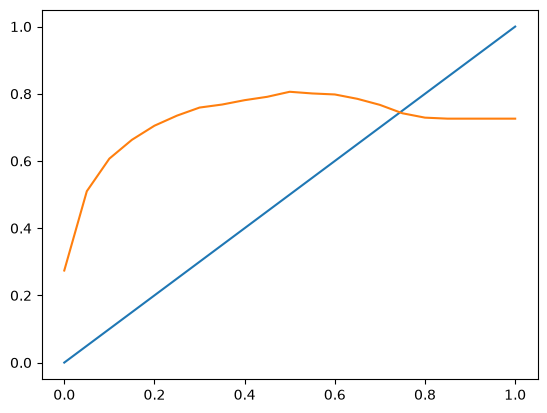

In [29]:
plt.plot(tresholds, scores)

#### The dummy model

In [30]:
from collections import Counter

In [31]:
Counter(y_pred >= 1.0)

Counter({np.False_: 1409})

In [32]:
1 - y_val.mean()

np.float64(0.7260468417317246)

### 4.3 Confusion table

In [33]:
actual_positives = (y_val == 1)
actual_negatives = (y_val == 0)

In [34]:
t = 0.5
predict_positives = (y_pred>=t)
predict_negatives = (y_pred<t)

In [35]:
tp = ( actual_positives & predict_positives).sum()
tn = ( actual_negatives & predict_negatives).sum()

fp = ( predict_positives & actual_negatives).sum()
fn = ( predict_negatives & actual_positives).sum()

In [36]:
tp, tn, fp, fn

(np.int64(214), np.int64(921), np.int64(102), np.int64(172))

In [37]:
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])

In [38]:
confusion_matrix

array([[921, 102],
       [172, 214]])

In [39]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.65, 0.07],
       [0.12, 0.15]])

### 4.4 Precision and Recall

In [40]:
precision = tp / (tp + fp)
precision

np.float64(0.6772151898734177)

In [41]:
recall = tp / (tp + fn)
recall

np.float64(0.5544041450777202)

### 4.5 ROC Curves

#### TPR and FRP

In [42]:
# TPR is the fraction of actual positives we identified correctly
tpr = tp / (tp + fn)
tpr

np.float64(0.5544041450777202)

In [43]:
# FPR is the fraction of actual negatives we got wrong
fpr = fp / (fp + tn)
fpr

np.float64(0.09970674486803519)

In [44]:
scores = []
thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positives = (y_val == 1)
    actual_negatives = (y_val == 0)

    predict_positives = (y_pred >= t)
    predict_negatives = (y_pred < t)

    tp = ( predict_positives & actual_positives).sum()
    tn = ( predict_negatives & actual_negatives).sum()
    fp = ( predict_positives & actual_negatives).sum()
    fn = ( predict_negatives & actual_positives).sum()
    scores.append((t, tp, fp, fn, tn))

In [45]:
columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)

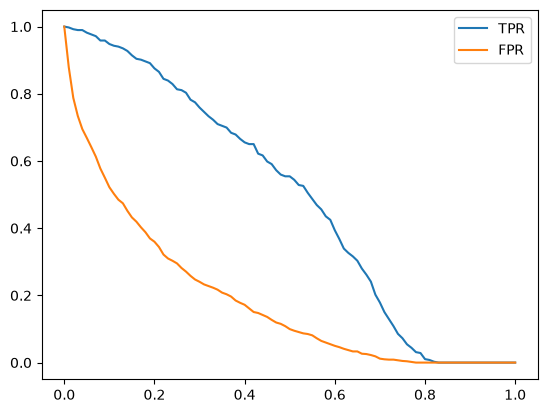

In [46]:
plt.plot(df_scores.threshold, df_scores.tpr, label = 'TPR')
plt.plot(df_scores.threshold, df_scores.fpr, label = 'FPR')
plt.legend()

#### Random model

In [47]:
np.random.seed(1)
y_rand = np.random.uniform(0, 1, size=len(y_val))

In [48]:
((y_rand >= 0.5) == y_val).mean()

np.float64(0.5017743080198722)

In [49]:
def tpr_fpr_dataframe(y_val, y_pred):
    scores = []
    
    thresholds = np.linspace(0, 1, 101)

    for t in thresholds:
        actual_positives = (y_val == 1)
        actual_negatives = (y_val == 0)
    
        predict_positives = (y_pred >= t)
        predict_negatives = (y_pred < t)
    
        tp = ( predict_positives & actual_positives).sum()
        tn = ( predict_negatives & actual_negatives).sum()
        fp = ( predict_positives & actual_negatives).sum()
        fn = ( predict_negatives & actual_positives).sum()
        
        scores.append((t, tp, fp, fn, tn))
        
    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)

    df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
    
    return df_scores

In [50]:
df_rand = tpr_fpr_dataframe(y_val, y_rand)

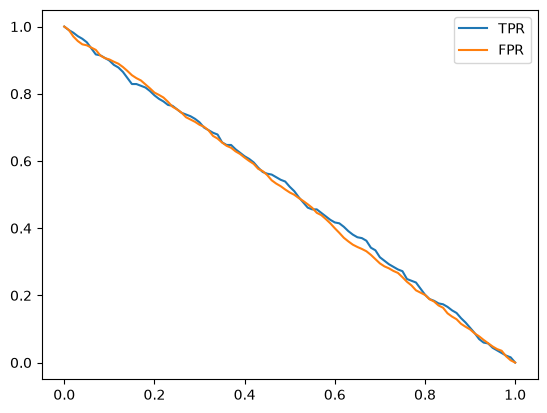

In [51]:
plt.plot(df_rand.threshold, df_rand.tpr, label='TPR')
plt.plot(df_rand.threshold, df_rand.fpr, label='FPR')
plt.legend()

#### Ideal model

In [52]:
num_pos = (y_val == 1).sum()
num_neg = (y_val == 0).sum()
num_neg, num_pos

(np.int64(1023), np.int64(386))

In [53]:
y_ideal = np.repeat([0, 1], [num_neg, num_pos])
y_ideal_pred = np.linspace(0, 1, len(y_val))

In [54]:
1 - y_val.mean()

np.float64(0.7260468417317246)

In [55]:
accuracy_score(y_ideal, y_ideal_pred>=0.726)

1.0

In [56]:
df_ideal = tpr_fpr_dataframe(y_ideal, y_ideal_pred)
df_ideal[::10]

,threshold,tp,fp,fn,tn,tpr,fpr
0,0.0,386,1023,0,0,1.000000,1.000000
10,0.1,386,882,0,141,1.000000,0.862170
20,0.2,386,741,0,282,1.000000,0.724340
30,0.3,386,600,0,423,1.000000,0.586510
40,0.4,386,459,0,564,1.000000,0.448680
50,0.5,386,319,0,704,1.000000,0.311828
60,0.6,386,178,0,845,1.000000,0.173998
70,0.7,386,37,0,986,1.000000,0.036168
80,0.8,282,0,104,1023,0.730570,0.000000
90,0.9,141,0,245,1023,0.365285,0.000000


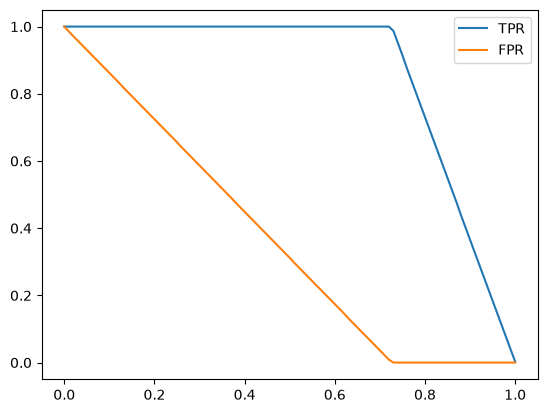

In [57]:
plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR')
plt.legend()

#### Putting everything together

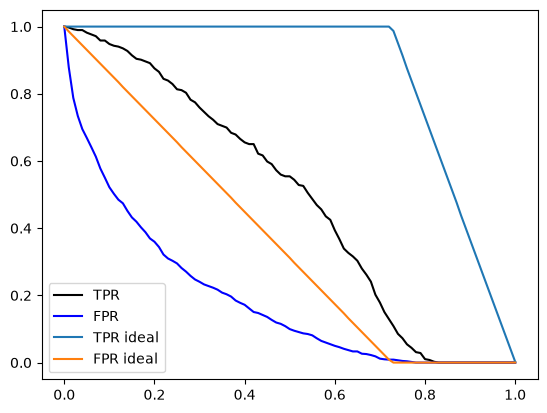

In [58]:
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR', color='black')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR', color='blue')

plt.plot(df_ideal.threshold, df_ideal['tpr'], label='TPR ideal')
plt.plot(df_ideal.threshold, df_ideal['fpr'], label='FPR ideal')

# plt.plot(df_rand.threshold, df_rand['tpr'], label='TPR random', color='grey')
# plt.plot(df_rand.threshold, df_rand['fpr'], label='FPR random', color='grey')

plt.legend()

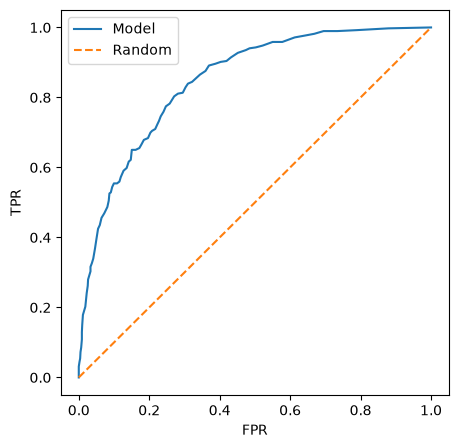

In [59]:
plt.figure(figsize=(5, 5))

plt.plot(df_scores.fpr, df_scores.tpr, label='Model')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

In [60]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

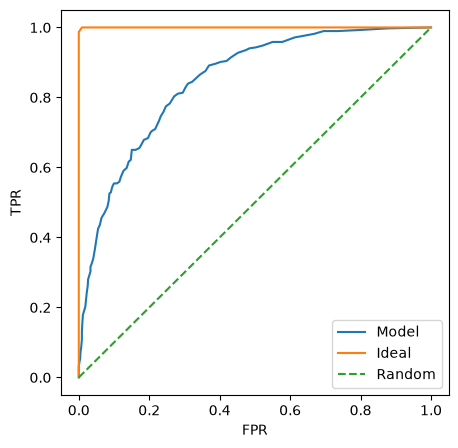

In [61]:
plt.figure(figsize=(5, 5))

plt.plot(df_scores.fpr, df_scores.tpr, label='Model')
plt.plot(df_ideal.fpr, df_ideal.tpr, label='Ideal')
plt.plot([0, 1], [0, 1], label='Random', linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')

plt.legend()

### 4.6 ROC AUC

In [62]:
from sklearn.metrics import auc

In [63]:
auc(fpr, tpr)

0.8464234523067885

In [64]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_val, y_pred)

0.8464234523067885

In [65]:
neg = y_pred[y_val == 0]
pos = y_pred[y_val == 1]

In [66]:
import random

n = 100000
success = 0

for i in range(n):
    pos_ind = random.randint(0, len(pos)-1)
    neg_ind = random.randint(0, len(neg)-1)
    if pos[pos_ind] > neg[neg_ind]:
        success += 1
        
success/n

0.84584

In [67]:
n = 50000

np.random.seed(1)
pos_ind = np.random.randint(0, len(pos), size=n)
neg_ind = np.random.randint(0, len(neg), size=n)

(pos[pos_ind] > neg[neg_ind]).mean()

np.float64(0.84888)

### 4.7 Cross-Validation

In [78]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)
    
    return dv, model

In [79]:
dv, model = train(df_train, y_train, C=0.001)

In [80]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [81]:
y_pred = predict(df_val, dv, model)

In [82]:
from sklearn.model_selection import KFold

In [83]:
!pip install tqdm

In [84]:
from tqdm.auto import tqdm

In [85]:
n_splits = 5

for C in tqdm([0.001, 0.01, 0.1, 0.5, 1, 5, 10]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.churn.values
        y_val = df_val.churn.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

  0%|          | 0/7 [00:00<?, ?it/s]

C=0.001 0.825 +- 0.013
C=0.01 0.840 +- 0.009
C=0.1 0.841 +- 0.008
C=0.5 0.841 +- 0.007
C=1 0.841 +- 0.007
C=5 0.841 +- 0.007
C=10 0.841 +- 0.007


In [86]:
scores

[0.8422102032325675,
 0.8452171070056945,
 0.8338310254866547,
 0.8322708160133018,
 0.8522167487684729]

In [87]:
dv, model = train(df_full_train, df_full_train.churn.values, C=1.0)
y_pred = predict(df_test, dv, model)

auc = roc_auc_score(y_test, y_pred)
auc

0.8579400803839363